<a href="https://colab.research.google.com/github/Asaf21S/flow-matching-as-a-layer/blob/main/notebooks/classifiers_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 1: Classification Baselines

This notebook implements and evaluates the Stage 1 classification baselines on frozen pretrained image encoders:

- **Datasets & Protocol**: DTD (47 classes, partition 1) and FGVC-Aircraft (100 classes, variant level). Uses official train, validation, and test splits ($K \in \{5, 10, \text{full}\}$ training images per class with seeds $\{0, 1, 2\}$).
- **Frozen Encoders**: ResNet-18 (ImageNet-1K, 512-dim), DINOv2 ViT-S/14 (384-dim), and CLIP RN50 (1024-dim).
- **Baselines**: Mandatory **Softmax Linear Probing** ($s = Wz + b$, AdamW optimizer) and **Option B: Zero-Shot CLIP** (text-derived prototypes).
- **Deliverables**: Top-1 accuracy summary table, accuracy vs. $K$ plots with error bars, linear probe training curves, row-normalized confusion matrices, and 2D feature projections (PCA & t-SNE).

## 1. Setup & Environment

In [3]:
%matplotlib inline

import os
import sys
import logging
import warnings
from pathlib import Path

# Suppress noisy library warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

import torch

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("/content/flow-matching-as-a-layer"):
        !git clone https://github.com/Asaf21S/flow-matching-as-a-layer.git
    %cd /content/flow-matching-as-a-layer
    !git pull --ff-only
    !pip install -q -r requirements-colab.txt

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
FEATURE_ROOT = REPO_ROOT / "features"
RESULTS_ROOT = REPO_ROOT / "results"

for path in (DATA_ROOT, FEATURE_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

os.environ["FMLAYER_DATA_ROOT"] = str(DATA_ROOT)
os.environ["FMLAYER_FEATURE_ROOT"] = str(FEATURE_ROOT)
os.environ["FMLAYER_RESULTS_ROOT"] = str(RESULTS_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

Cloning into 'flow-matching-as-a-layer'...
remote: Enumerating objects: 153, done.
remote: Counting objects: 100% (153/153), done.
remote: Compressing objects: 100% (118/118), done.
remote: Total 153 (delta 60), reused 119 (delta 34), pack-reused 0 (from 0)
Receiving objects: 100% (153/153), 4.25 MiB | 28.46 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/flow-matching-as-a-layer
Already up to date.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00
Environment: Colab
PyTorch: 2.11.0+cu128 | CUDA: True


## 2. Dataset Preparation

In [4]:
from src.fmlayer.data.prepare import prepare_datasets

report = prepare_datasets()
for key, info in report["datasets"].items():
    print(f"{info['display_name']} ({info['num_classes']} classes): ready.")

Data root: /content/flow-matching-as-a-layer/data

=== FGVC-Aircraft (aircraft) ===
    protocol: {'annotation_level': 'variant'}, approx. 2750 MB


100%|██████████| 2.75G/2.75G [01:43<00:00, 26.7MB/s]


    [ok] train   3334 images, 100 classes, 33-34 per class
    [ok] val     3333 images, 100 classes, 33-34 per class
    [ok] test    3333 images, 100 classes, 33-34 per class
    prompt: 'a photo of a 707-320 aircraft' ... 'a photo of a Yak-42 aircraft'
=== DTD (dtd) ===
    protocol: {'partition': 1}, approx. 625 MB


100%|██████████| 625M/625M [00:22<00:00, 28.1MB/s]


    [ok] train   1880 images, 47 classes, 40-40 per class
    [ok] val     1880 images, 47 classes, 40-40 per class
    [ok] test    1880 images, 47 classes, 40-40 per class
    prompt: 'a photo of a banded texture' ... 'a photo of a zigzagged texture'
FGVC-Aircraft (100 classes): ready.
DTD (47 classes): ready.


## 3. Pretrained Encoders & Feature Extraction

In [5]:
from src.fmlayer.encoders.check import smoke_test_encoders
from src.fmlayer.features.extract import extract_all

smoke_test_encoders()
cached_paths = extract_all()
print(f"Cached feature splits across {len(cached_paths)} files.")

Device: cuda

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 130MB/s]


[ok] resnet18       input (3, 224, 224) -> features (2, 512)
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 324MB/s]


[ok] dinov2_vits14  input (3, 224, 224) -> features (2, 384)


...

    [ok]     clip_rn50/aircraft/train -> (3334, 1024) aircraft_train.npz


clip_rn50/aircraft/val:   0%|          | 0/53 [00:00<?, ?it/s]

    [ok]     clip_rn50/aircraft/val -> (3333, 1024) aircraft_val.npz


clip_rn50/aircraft/test:   0%|          | 0/53 [00:00<?, ?it/s]

    [ok]     clip_rn50/aircraft/test -> (3333, 1024) aircraft_test.npz
    [ok]     clip_rn50/aircraft/text -> (100, 1024) aircraft_text.npz

17 feature files ready.
Cached feature splits across 17 files.


## 4. Option B Baseline: Zero-Shot CLIP

In [6]:
from src.fmlayer.models.zeroshot import run_zeroshot_all

zeroshot_results = run_zeroshot_all()

[FGVC-Aircraft] zero-shot CLIP RN50: 0.1545 top-1 on 3333 test images
    prompt example: 'a photo of a 707-320 aircraft'
[DTD] zero-shot CLIP RN50: 0.4005 top-1 on 1880 test images
    prompt example: 'a photo of a banded texture'


## 5. Subsets & Linear Probe Baseline

In [7]:
from src.fmlayer.data.fewshot import build_all_subsets
from src.fmlayer.train.train_linear import run_all_linear_probes

build_all_subsets()
probe_results = run_all_linear_probes()


=== dtd (1880 training images, 47 classes) ===
    k=5    seed=0    235 images, 5-5 per class
    k=5    seed=1    235 images, 5-5 per class
    k=5    seed=2    235 images, 5-5 per class
    k=10   seed=0    470 images, 10-10 per class
    k=10   seed=1    470 images, 10-10 per class
    k=10   seed=2    470 images, 10-10 per class
    k=full seed=0   1880 images, 40-40 per class

=== aircraft (3334 training images, 100 classes) ===
    k=5    seed=0    500 images, 5-5 per class
    k=5    seed=1    500 images, 5-5 per class
    k=5    seed=2    500 images, 5-5 per class
    k=10   seed=0   1000 images, 10-10 per class
    k=10   seed=1   1000 images, 10-10 per class
    k=10   seed=2   1000 images, 10-10 per class
    k=full seed=0   3334 images, 33-34 per class
Device: cuda


linear probes:   0%|          | 0/27 [00:00<?, ?it/s]

    resnet18       dtd       k=5    seed=0  train=  235  val=0.4489@125  test=0.4628
    resnet18       dtd       k=5    seed=1  train=  235  val=0.4553@31   test=0.4420
    resnet18       dtd       k=5    seed=2  train=  235  val=0.4309@150  test=0.4495
    resnet18       dtd       k=10   seed=0  train=  470  val=0.5074@32   test=0.5399
    resnet18       dtd       k=10   seed=1  train=  470  val=0.5383@65   test=0.5383
    resnet18       dtd       k=10   seed=2  train=  470  val=0.5144@27   test=0.5553
    resnet18       dtd       k=full seed=0  train= 1880  val=0.6085@23   test=0.6335
    resnet18       dtd       k=full seed=1  train= 1880  val=0.6064@16   test=0.6255
    resnet18       dtd       k=full seed=2  train= 1880  val=0.6064@18   test=0.6261
    resnet18       aircraft  k=5    seed=0  train=  500  val=0.1869@75   test=0.1794
    resnet18       aircraft  k=5    seed=1  train=  500  val=0.2055@182  test=0.2010
    resnet18       aircraft  k=5    seed=2  train=  500  val=0.20

## 6. Deliverables & Visualizations

### 6.1 Top-1 Accuracy Table

In [8]:
from src.fmlayer.report import accuracy_table, print_accuracy_table

table = accuracy_table()
print_accuracy_table(table)


=== FGVC-Aircraft ===
  clip_zeroshot  clip_rn50      K=none  0.1545 +/- 0.0000  (n=1)
  linear_probe   resnet18       K=5     0.1972 +/- 0.0162  (n=3)
  linear_probe   resnet18       K=10    0.2720 +/- 0.0056  (n=3)
  linear_probe   resnet18       K=full  0.3662 +/- 0.0027  (n=3)

=== DTD ===
  clip_zeroshot  clip_rn50      K=none  0.4005 +/- 0.0000  (n=1)
  linear_probe   dinov2_vits14  K=5     0.6234 +/- 0.0014  (n=3)
  linear_probe   dinov2_vits14  K=10    0.6952 +/- 0.0074  (n=3)
  linear_probe   dinov2_vits14  K=full  0.7637 +/- 0.0083  (n=3)
  linear_probe   resnet18       K=5     0.4514 +/- 0.0105  (n=3)
  linear_probe   resnet18       K=10    0.5445 +/- 0.0094  (n=3)
  linear_probe   resnet18       K=full  0.6284 +/- 0.0045  (n=3)


### 6.2 Top-1 Accuracy vs. Training-Set Size (K)

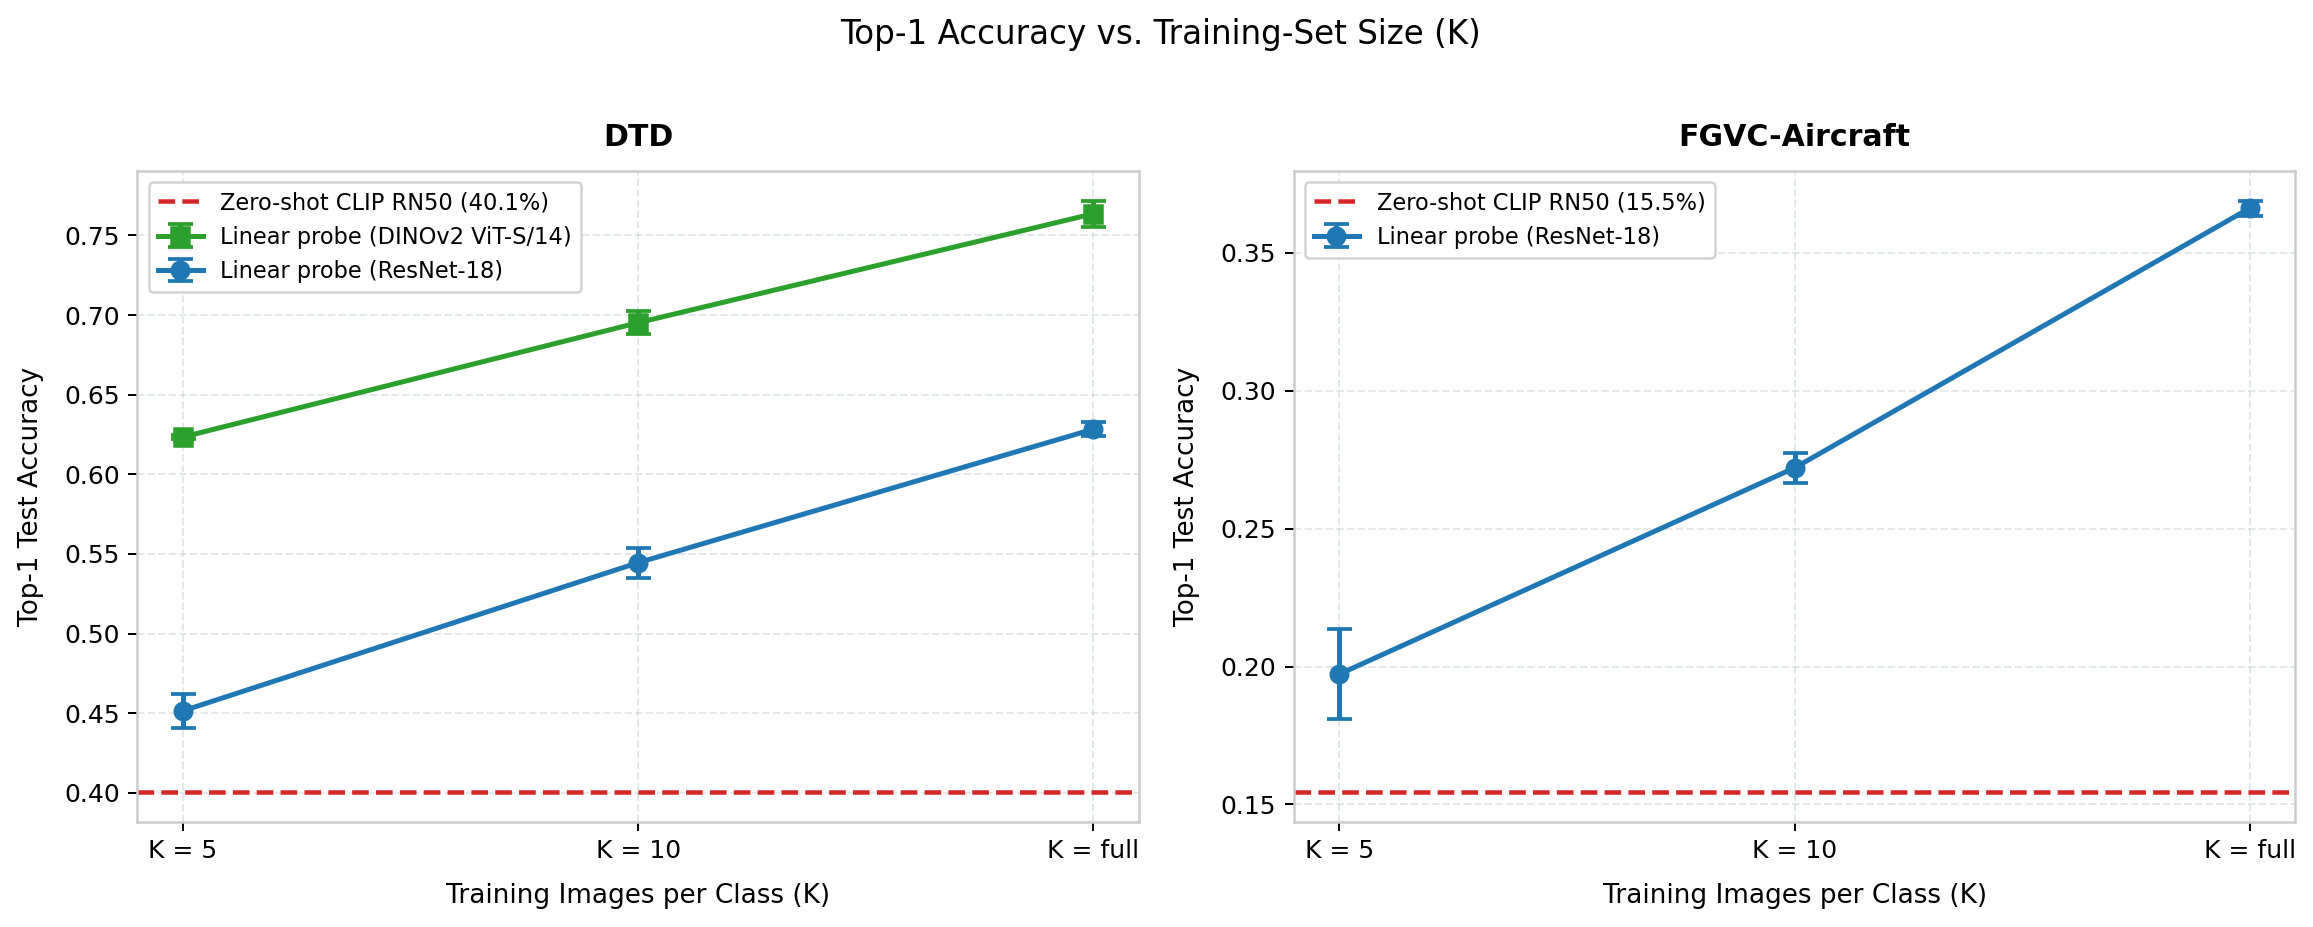

In [9]:
from src.fmlayer.viz.accuracy import plot_combined_accuracy_vs_k

plot_combined_accuracy_vs_k(table)

### 6.3 Linear Probe Training Curves

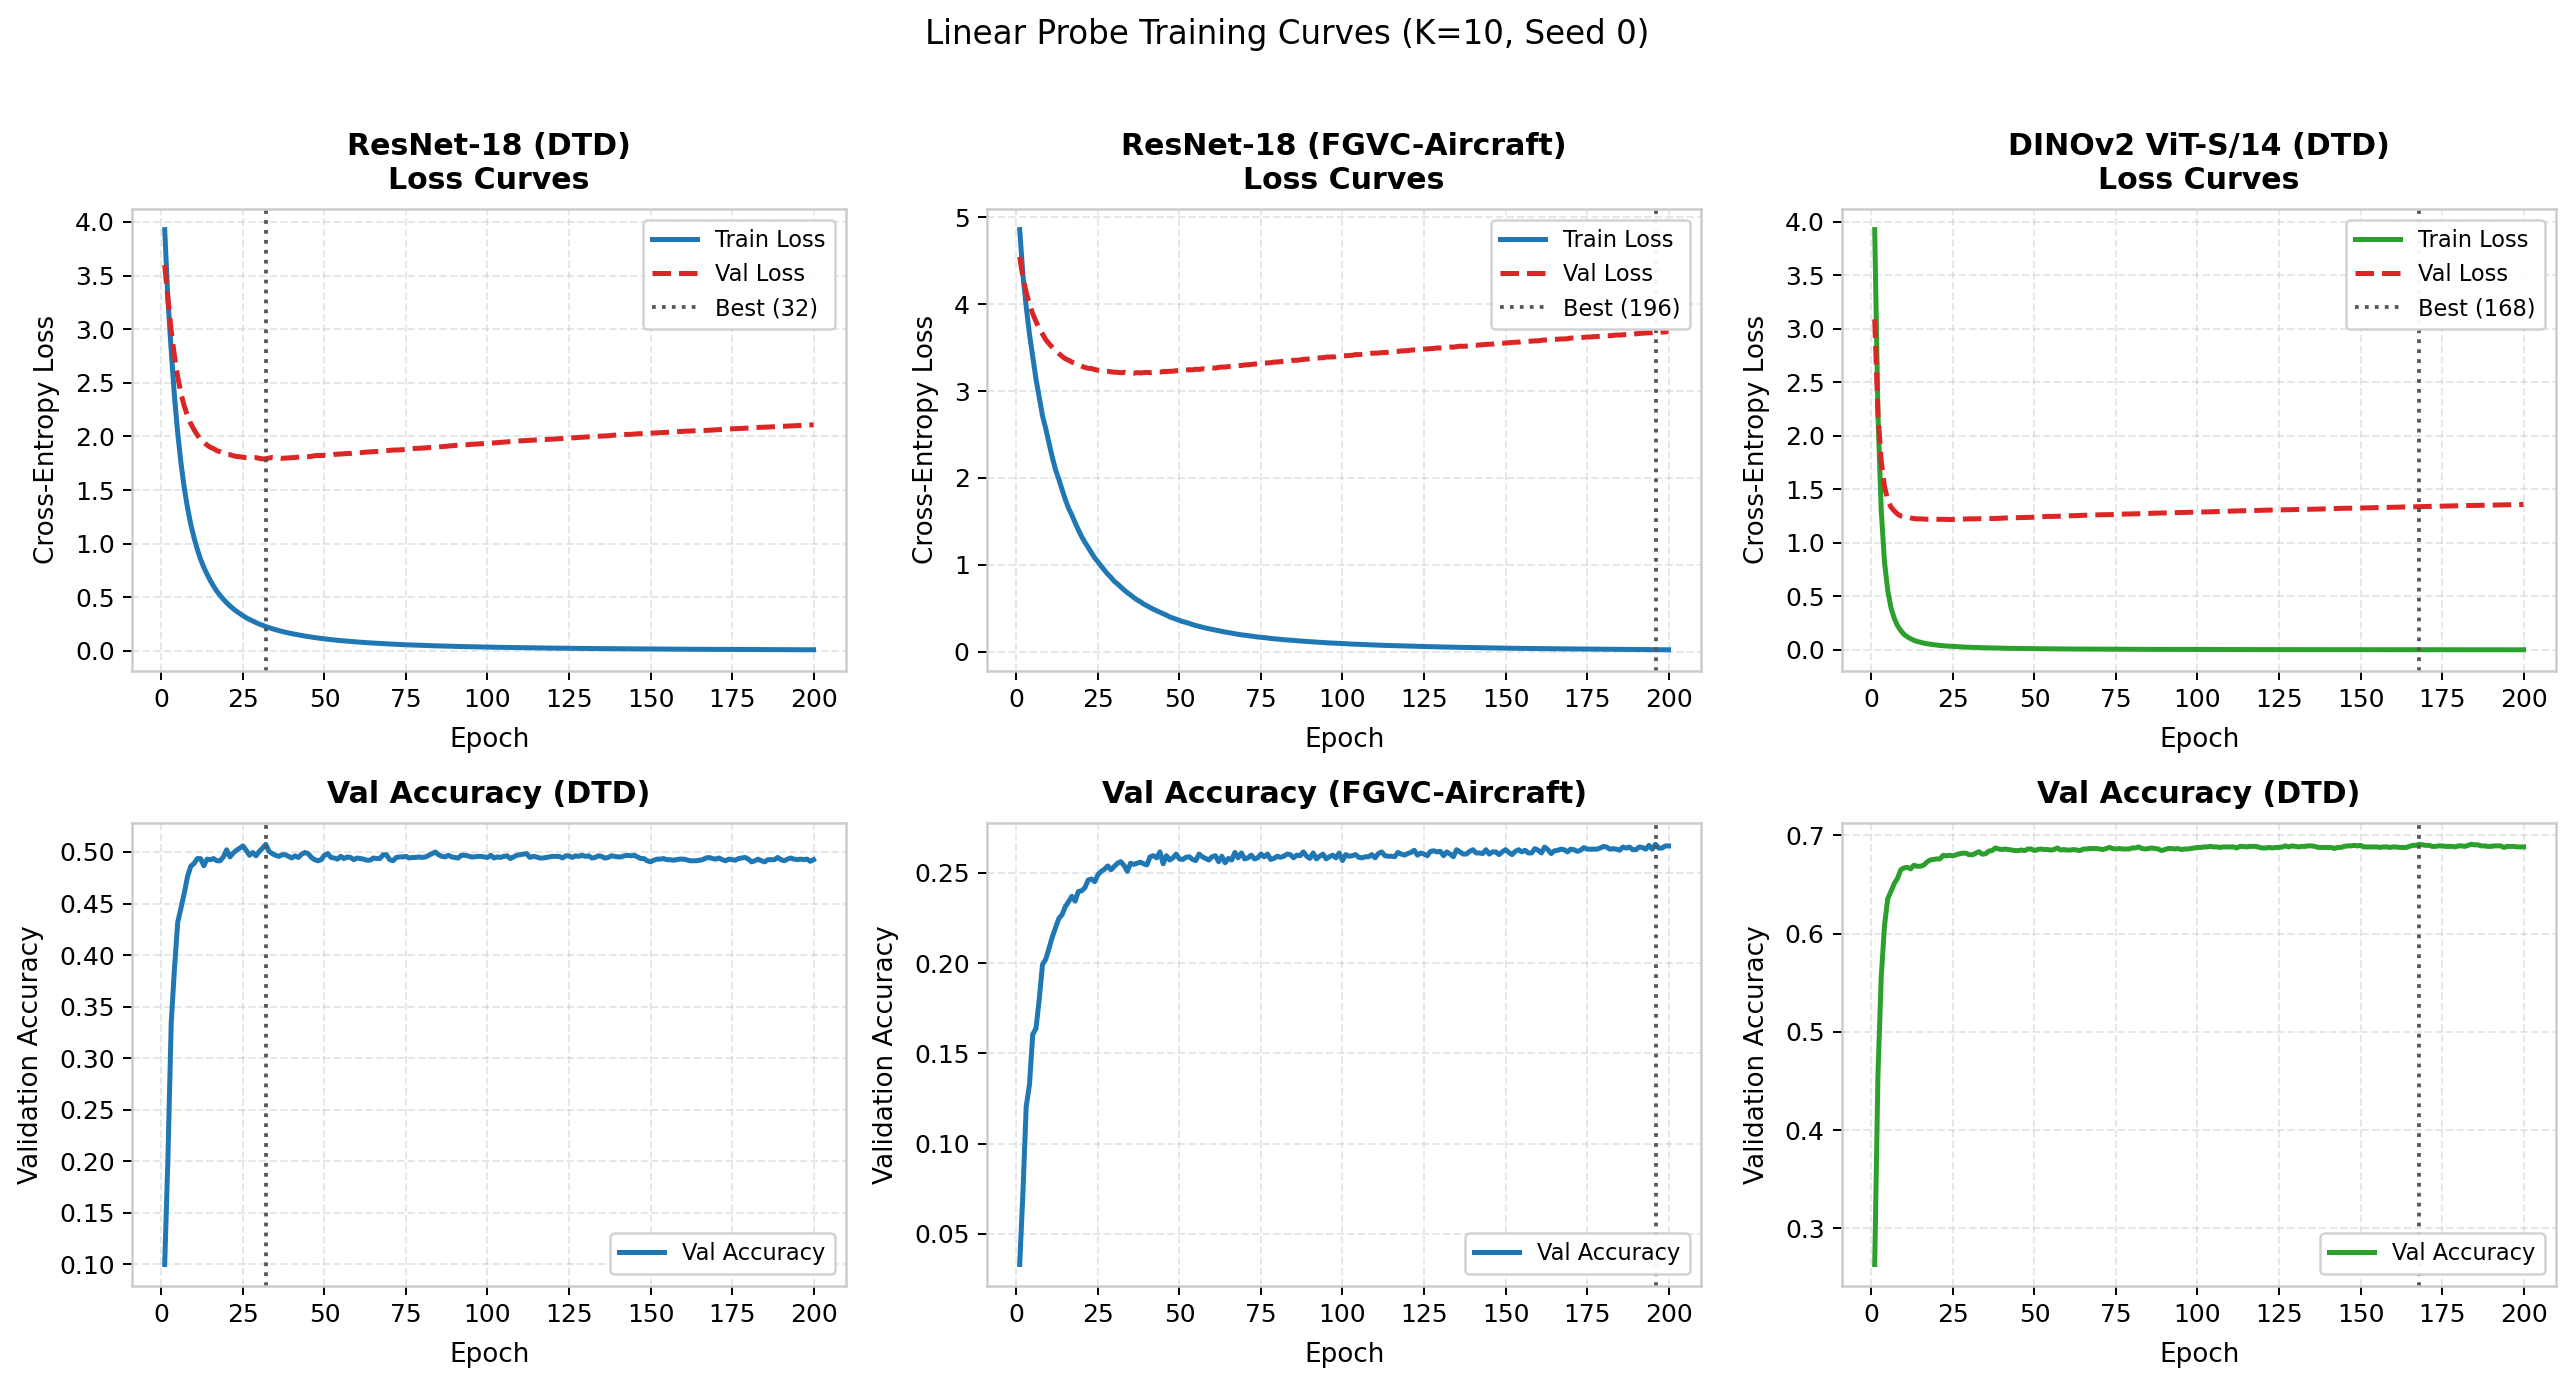

In [10]:
from src.fmlayer.viz.curves import plot_combined_curves

plot_combined_curves(k=10, seed=0)

### 6.4 Confusion Matrices

[DTD] zero-shot CLIP RN50: 0.4005 top-1 on 1880 test images
    prompt example: 'a photo of a banded texture'
[FGVC-Aircraft] zero-shot CLIP RN50: 0.1545 top-1 on 3333 test images
    prompt example: 'a photo of a 707-320 aircraft'


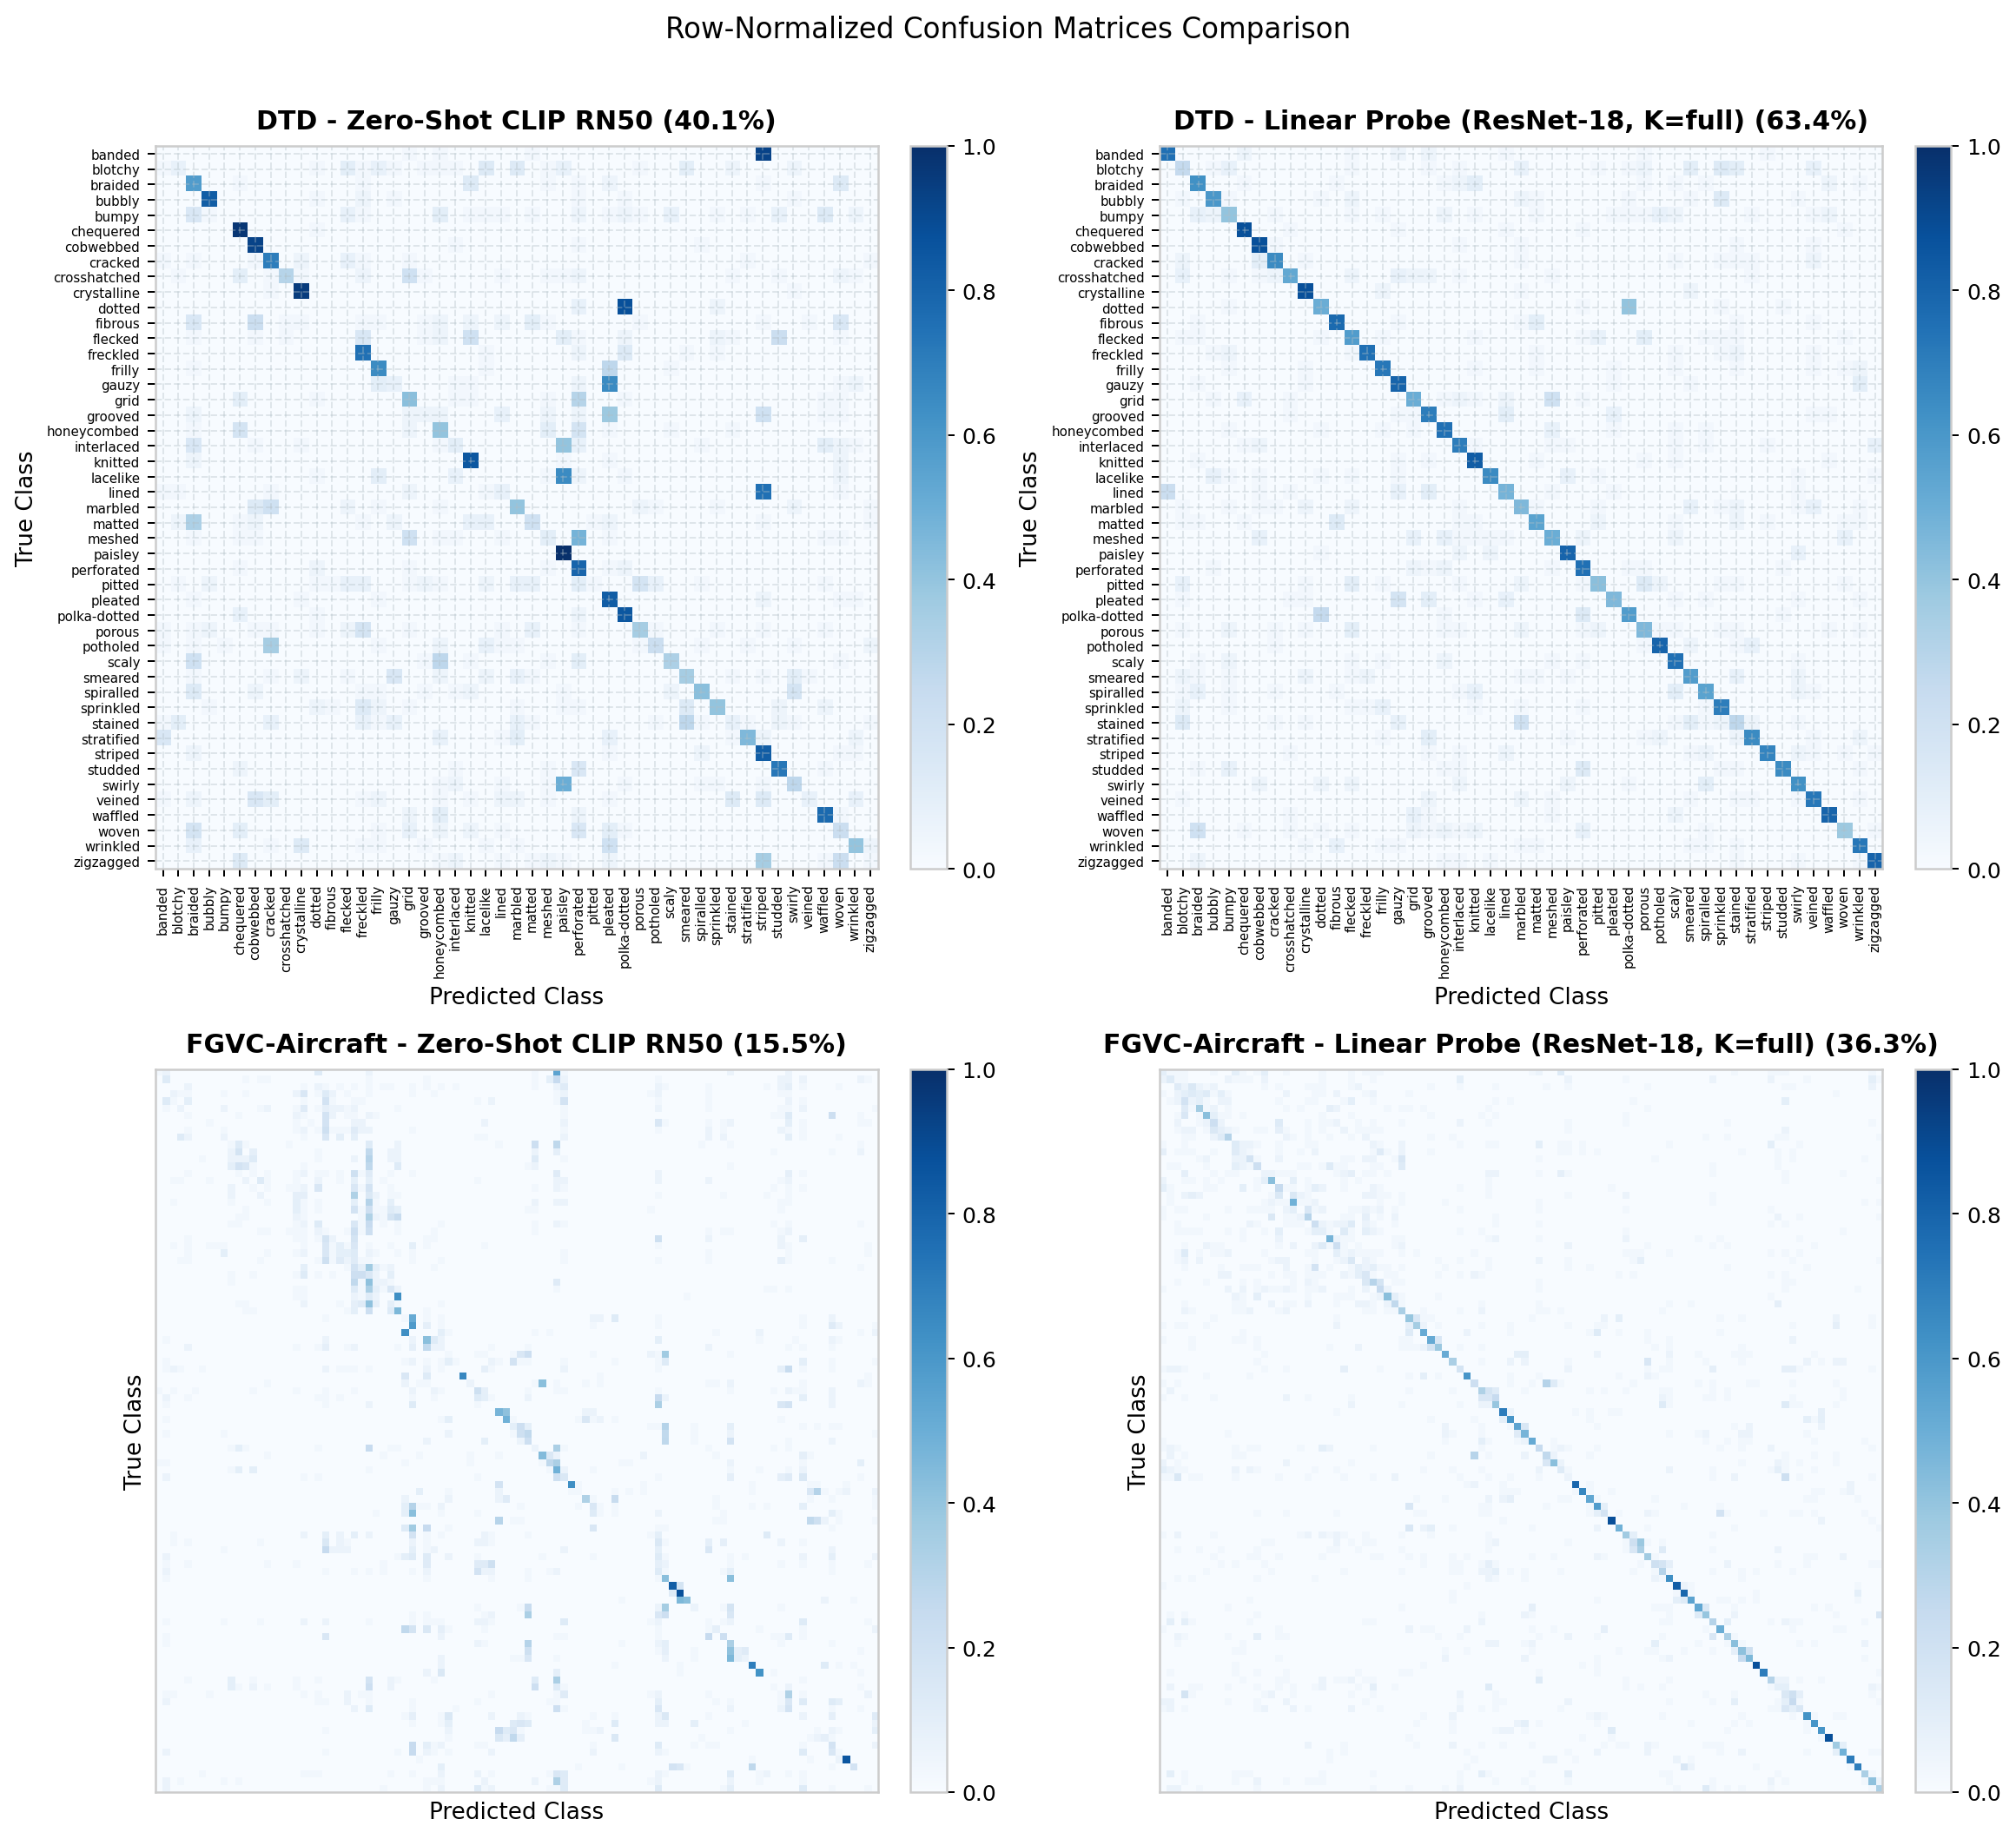

In [11]:
from src.fmlayer.viz.confusion import plot_combined_confusion

plot_combined_confusion(k="full", seed=0)

### 6.5 2D Feature Visualizations (PCA & t-SNE)

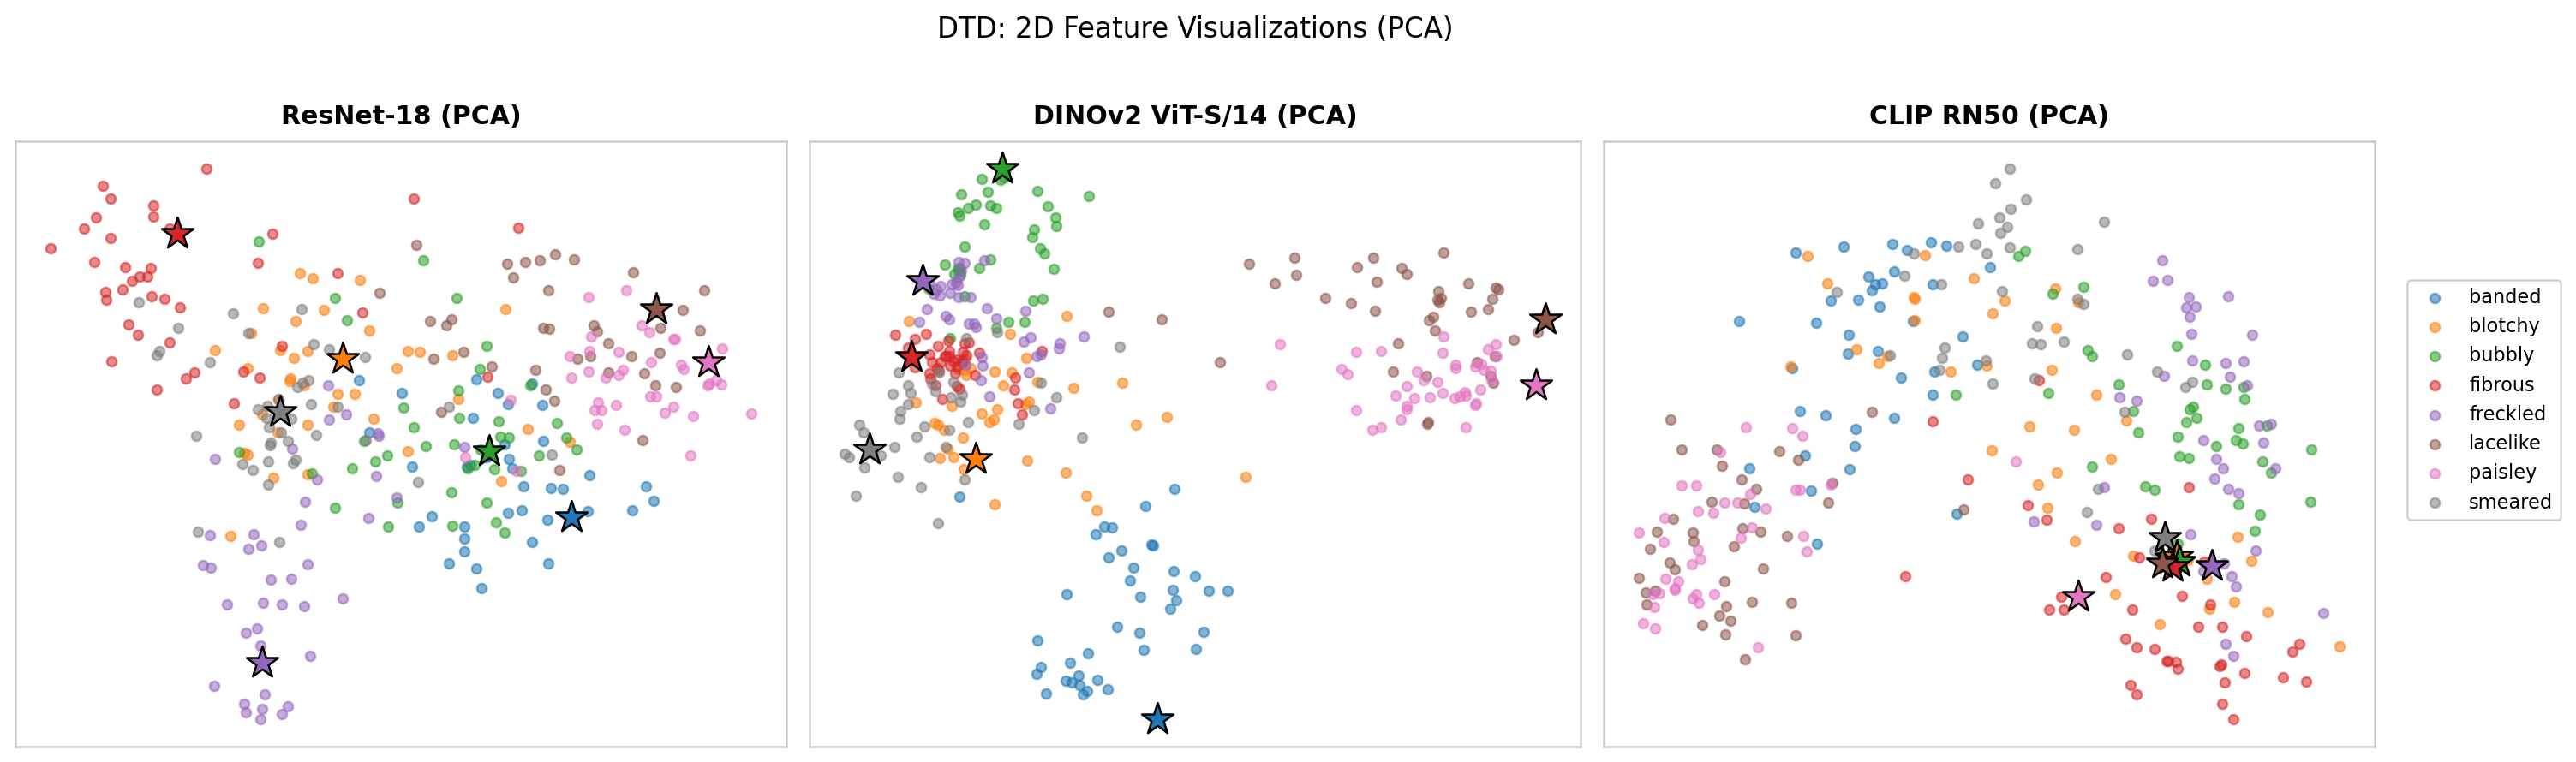

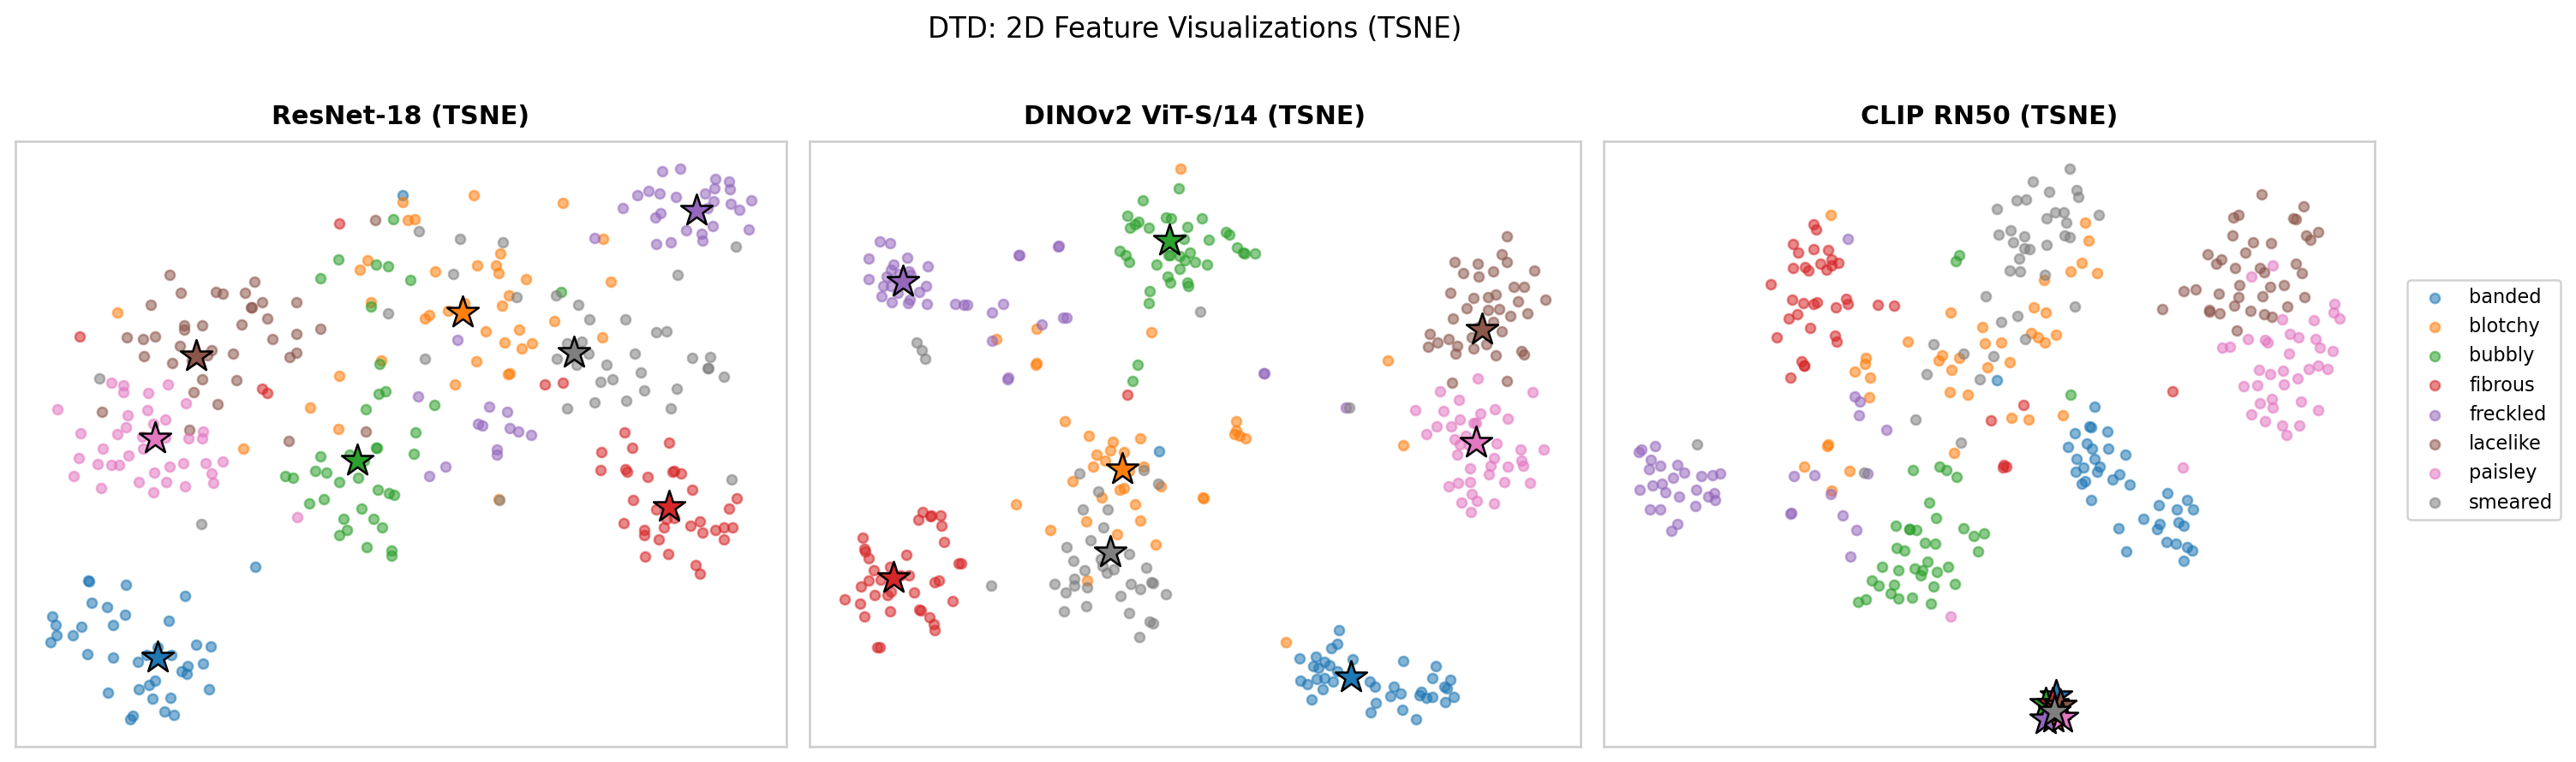

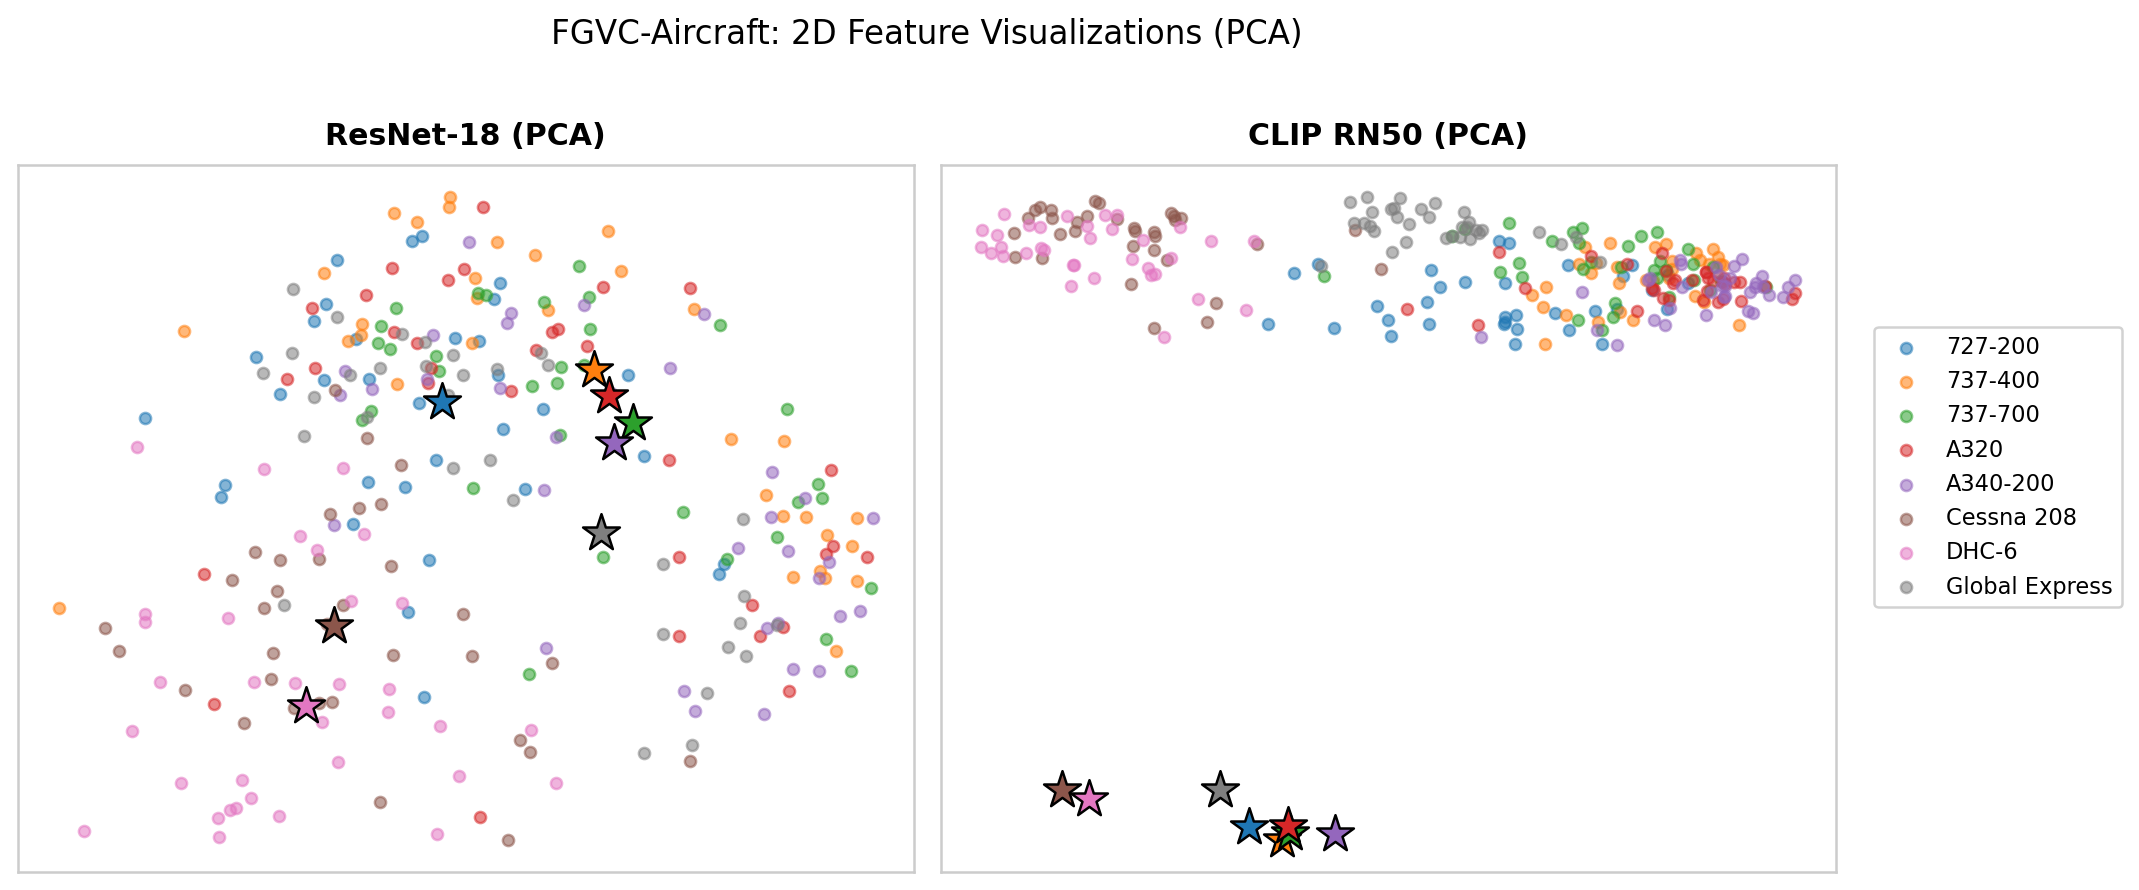

In [12]:
from src.fmlayer.viz.embeddings import plot_combined_embeddings_for_dataset

plot_combined_embeddings_for_dataset("dtd", method="pca")
plot_combined_embeddings_for_dataset("dtd", method="tsne")
plot_combined_embeddings_for_dataset("aircraft", method="pca")